# Consigna

Senoidal de frecuencia 
potencia normalizada, es decir energía (o varianza) unitaria
Se pide:

a) Sea <math xmlns="http://www.w3.org/1998/Math/MathML">
  <msub>
    <mi>k</mi>
    <mn>0</mn>
  </msub>
  <mo>=</mo>
  <mo fence="false" stretchy="false">{</mo>
  <mi>N</mi>
  <mrow data-mjx-texclass="ORD">
    <mo>/</mo>
  </mrow>
  <mn>4</mn>
  <mo>,</mo>
  <mi>N</mi>
  <mrow data-mjx-texclass="ORD">
    <mo>/</mo>
  </mrow>
  <mn>4</mn>
  <mo>+</mo>
  <mn>0.25</mn>
  <mo>,</mo>
  <mi>N</mi>
  <mrow data-mjx-texclass="ORD">
    <mo>/</mo>
  </mrow>
  <mn>4</mn>
  <mo>+</mo>
  <mn>0.5</mn>
  <mo fence="false" stretchy="false">}</mo>
</math>
. Notar que a cada senoidal se le agrega una pequeña desintonía respecto a  <math xmlns="http://www.w3.org/1998/Math/MathML">
  <msub>
    <mi mathvariant="normal">&#x394;</mi>
    <mi>f</mi>
  </msub>
</math>
. Graficar las tres densidades espectrales de potencia (PDS's) y discutir cuál es el efecto de dicha desintonía en el espectro visualizado.

b) Verificar la potencia unitaria de cada PSD. En base a la teoría estudiada, ¿cuál es la razón por la cual una señal senoidal tiene un espectro (PSD) tan diferente respecto a otra de muy pocos Hertz de diferencia?



# Funciones Previas

Funciones de resoluciones anteriores. Para un uso correcto deberían guardarse en un archivo Python (.py) en una carpeta lib para utilización como librerías. 

A fines prácticos, se copiarán acá

In [126]:
import numpy as np
import matplotlib.pyplot as plt

def mi_funcion_sen( vmax = 1, dc = 0, ff = 1, ph = 0, nn = 100, fs = 1000 ) -> tuple[np.ndarray,np.ndarray]:
    ts = 1/fs
    tt: np.ndarray = np.arange(stop=nn*ts, step=ts)

    xx = vmax * np.sin(2*np.pi*ff*tt + ph) + dc
    xx = np.array(xx).reshape(nn,1)
    tt = tt.reshape(nn,1)

    return xx, tt

def mi_funcion_cuadrada(vmax = 1, dc = 0, ff = 1, duty = .5, nn = 100, fs = 1000 ) -> tuple[np.ndarray,np.ndarray] :
    ts = 1/fs
    tt: np.ndarray = np.arange(stop=nn*ts, step=ts)

    xx = np.where(tt % (1/ff) < (1/ff) * duty, 1, -1)
    xx = vmax * xx + dc
    #signal.square(2* np.pi * ff* tt, duty)

    tt = tt.reshape(nn,1)
    xx = np.array(xx).reshape(nn,1)

    return xx, tt

def mi_funcion_triangular(vmax = 1, dc = 0, ff = 1, nn = 1, fs = 1000) -> tuple[np.ndarray,np.ndarray]:
    ts = 1/fs
    tt: np.ndarray = np.arange(stop= nn*ts, step=ts)
    T = 1/ff

    xx = [((vmax/T) * (i%T) + dc) for i in tt]
    #signal.sawtooth(2* np.pi * ff* tt, 0.5)

    tt = tt.reshape(nn,1)
    xx = np.array(xx).reshape(nn,1)

    return xx, tt

def noise_generator(var = 1, nn = 100, fs = 1000) -> tuple[np.ndarray,np.ndarray]:
    '''noise_generator(var = 1, nn = 100, fs = 1000) -> tuple[np.ndarray,np.ndarray]:
        Generates Gaussian noise, with variance var and zero mean.

        Note: This distribution corresponds to "white noise". (Extracted from ASYS notes, Stochastic process - White Noise)
    '''
    ts = 1/fs
    tt: np.ndarray = np.arange(stop=nn*ts, step=ts)

    xx = np.random.normal(loc=0, scale=np.sqrt(var), size=nn)

    tt = tt.reshape(nn,1)
    xx = np.array(xx).reshape(nn,1)

    return xx, tt

def mi_sen_ruidosa( vmax = 1, dc = 0, ff = 1, ph = 0, nn = 100, fs = 1000, snr = 20) -> tuple[np.ndarray,np.ndarray]:
    xx, tt = mi_funcion_sen(vmax=vmax, dc=dc, ff=ff, ph=ph, nn=nn, fs=fs)
    pot_signal = np.mean(xx**2)
    var_noise = pot_signal / (10**(snr/10))  # Calculando potencia de señal conocida "senoidal"
    # var_noise = power(xx) / (10**(snr/10))    # Lo mismo, calculando potencia por definicion
    
    noise, _ = noise_generator(var_noise, nn, fs)
    xx = xx + noise

    return xx, tt

def power(x: np.ndarray) -> float:
    return np.mean(x**2)

def snr(signal: np.ndarray, noise: np.ndarray) -> float:
    return 10 * np.log10(np.mean(signal**2) / np.mean(noise**2))

def mi_adc(xx, Vfs, bits=4):
    '''mi_adc
    Quantizes the signal xx like an ADC with Vfs and bits.
    xx: Signal to be quantized.
    Vfs: ADC [0, Vfs]
    bits: Number of bits of the ADC.
    ''' 
    q = Vfs/(2**bits) 
    xq = np.round(xx/q) * q
    vmax =  q*(2**(bits-1)-1)
    vmin = -q*2**(bits-1)

    np.clip(xq, vmin, vmax, out=xq)
    #xq[xq > vmax] = vmax
    #xq[xq < vmin] = vmin
    return xq

def autocorrelate(xx: np.ndarray) -> np.ndarray:
    xx = np.asarray(xx).flatten()

    autocorr = np.correlate(xx, xx, mode='full')/xx.size        # Normalizated to size. Gives the true values of the autocorrelation
    autocorr = autocorr[autocorr.size//2:]                      # Only keep non negative values
    autocorr = autocorr.reshape(-1,1)                           # Reshape to column vector (standard of PDS)
    return autocorr

def mod_db(xx: np.ndarray) -> np.ndarray:
    return 20*np.log10(np.abs(xx))

def mod_dbw(xx: np.ndarray) -> np.ndarray:
    return 10*np.log10(np.abs(xx))

def freq_axis(xx: np.ndarray, fs: float) -> np.ndarray:
    '''freq_axis
    
    Equal to np.fft.fftfreq. It generates the correct freq axis for the fft algorithm.
    Axis has the form:
    [0, △f, 2△f, ..., fs/2, -fs/2, -(fs/2-△f), ..., -△f]
    Note: the positive half always starts with 0. The negative half always starts with -fs/2, so, the negative half has one extra value if the length of the signal is even.
    xx: signal to generate the axis for. Only the length is used.
    fs: sampling frequency
    '''
    nn = xx.shape[0]
    half = np.arange(0, fs/2, fs/nn)
    ff = np.concatenate((half, -half[::-1] - fs/nn))
    ff = ff[:nn]
    return ff.reshape(-1,1)

# Respuesta

Funciones de resoluciones anteriores. Para un uso correcto deberían guardarse en un archivo Python (.py) en una carpeta lib para utilización como librerías. 

A fines prácticos, se copiarán acá

In [127]:
1+1

2

In [ ]:
from scipy import signal
####### VALORES 
N = 2000
fs = 2000
vmax = 2**.5
snr = 10
f0 = fs/4

cant_muestras = 200

win_rect = np.ones(N).reshape(-1,1)
win_flattop = signal.windows.flattop(N).reshape(-1,1)
win_blackman = signal.windows.blackman(N).reshape(-1,1)
win_hamming = signal.windows.hamming(N).reshape(-1,1)

def check_estimador(win):
    fr = np.random.uniform(-2,2, cant_muestras)
    freq = fr + f0

    xx = []
    for f in freq:
        x_aux, _ = mi_sen_ruidosa(vmax=vmax, ff=f, nn=N, fs=fs, snr=snr) * win/np.mean(win)
        if len(xx) == 0:
            xx = x_aux
        else:
            xx = np.hstack((xx, x_aux))

    xx_fft = np.fft.fft(xx, axis=0)/N
    xx_fft_abs = np.abs(xx_fft)
    a_estimado = 2*xx_fft_abs[500,:]

    return xx_fft_abs, a_estimado


def check_est_v2(xx):
    xx_fft = np.fft.fft(xx, axis=0)/N
    xx_fft_abs = np.abs(xx_fft)
    a_estimado = 2*xx_fft_abs[500,:]

    return xx_fft_abs, a_estimado


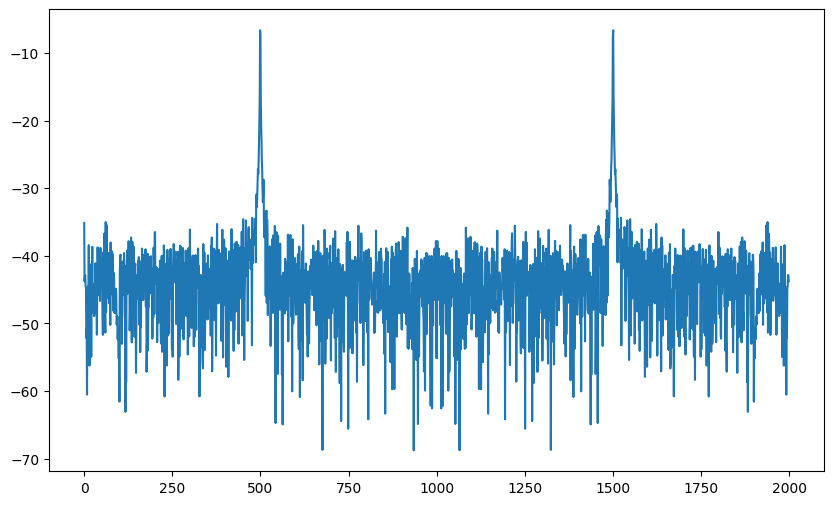

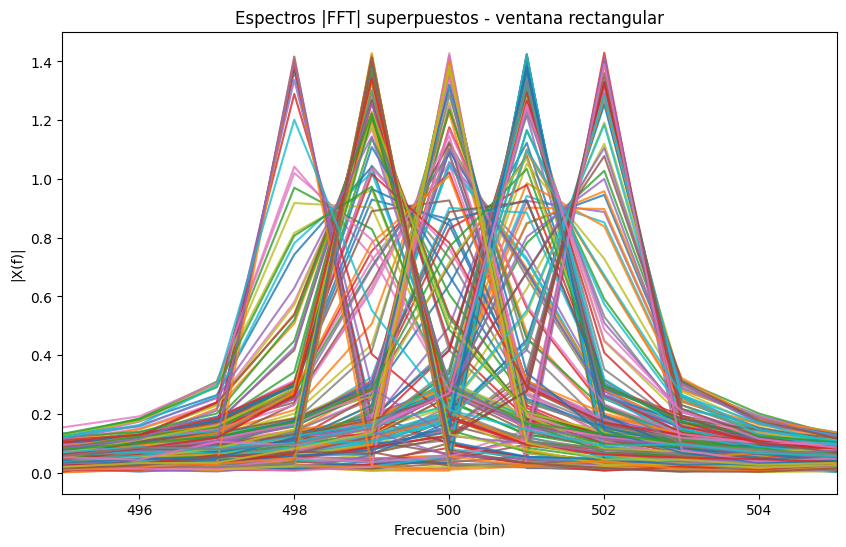

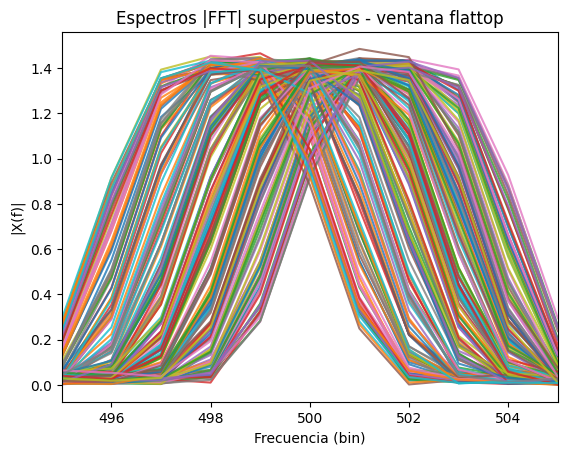

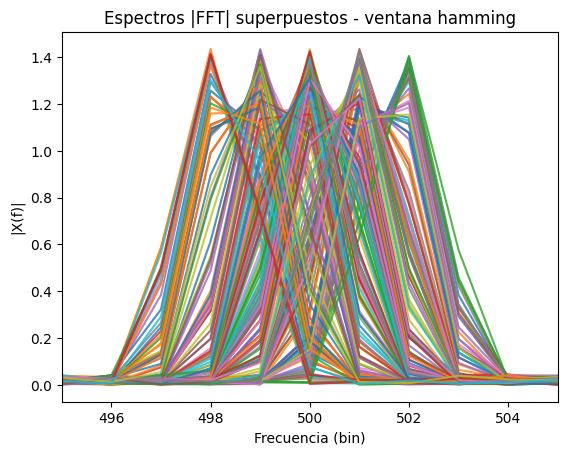

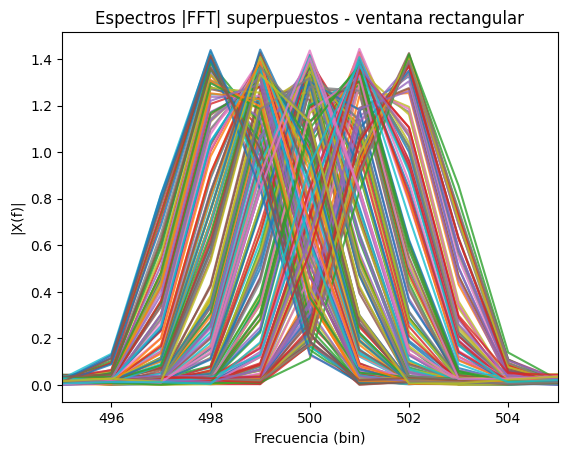

In [129]:
a_est = {}
xx_fft_abs = {}
xx_fft_abs["rect"], a_est["rect"] = check_estimador(win_rect)
xx_fft_abs["flattop"], a_est["flattop"] = check_estimador(win_flattop)
xx_fft_abs["black"], a_est["black"] = check_estimador(win_blackman)
xx_fft_abs["ham"], a_est["ham"] = check_estimador(win_hamming)

plt.figure(figsize=(10,6))
plt.plot(20*np.log10(xx_fft_abs["rect"][:,0]))
plt.show()

plt.figure(figsize=(10,6))

for i in range(xx_fft_abs["rect"].shape[1]):
    plt.plot(2*xx_fft_abs["rect"][:, i], alpha=0.8)

plt.xlim(f0*0.99, f0*1.01)
plt.title("Espectros |FFT| superpuestos - ventana rectangular")
plt.xlabel("Frecuencia (bin)")
plt.ylabel("|X(f)|")

plt.show()

for i in range(xx_fft_abs["flattop"].shape[1]):
    plt.plot(2*xx_fft_abs["flattop"][:, i], alpha=0.8)

plt.xlim(f0*0.99, f0*1.01)
plt.title("Espectros |FFT| superpuestos - ventana flattop")
plt.xlabel("Frecuencia (bin)")
plt.ylabel("|X(f)|")

plt.show()

for i in range(xx_fft_abs["ham"].shape[1]):
    plt.plot(2*xx_fft_abs["ham"][:, i], alpha=0.8)

plt.xlim(f0*0.99, f0*1.01)
plt.title("Espectros |FFT| superpuestos - ventana hamming")
plt.xlabel("Frecuencia (bin)")
plt.ylabel("|X(f)|")

plt.show()

for i in range(xx_fft_abs["black"].shape[1]):
    plt.plot(2*xx_fft_abs["black"][:, i], alpha=0.8)

plt.xlim(f0*0.99, f0*1.01)
plt.title("Espectros |FFT| superpuestos - ventana rectangular")
plt.xlabel("Frecuencia (bin)")
plt.ylabel("|X(f)|")

plt.show()


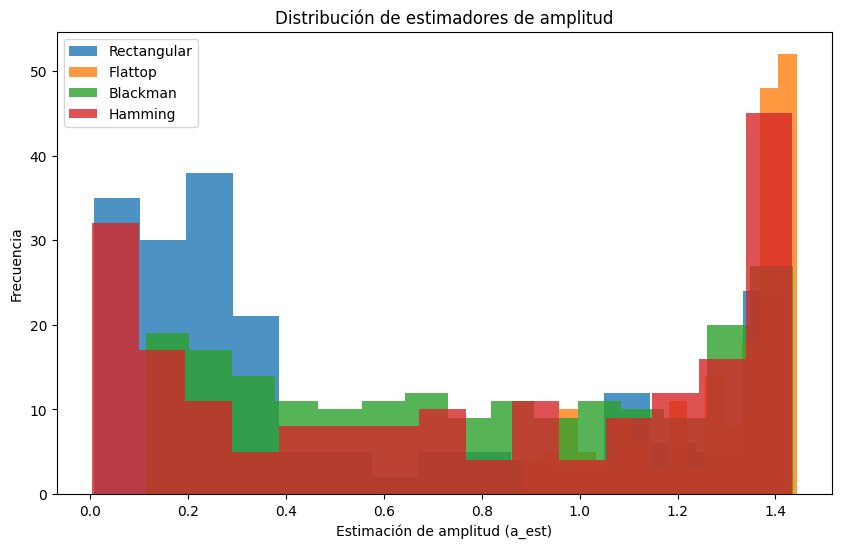

rectangular: 0.898744180101858
flattop: 0.12630354643043756
black: 0.6183358263116219
ham: 0.6511039504280797


In [130]:
# Histograma para cada ventana
plt.figure(figsize=(10,6))
bins = 15 
alpha = .8
plt.hist(a_est["rect"], bins=bins, alpha=alpha, label="Rectangular")
plt.hist(a_est["flattop"], bins=bins, alpha=alpha, label="Flattop")
plt.hist(a_est["black"], bins=bins, alpha=alpha, label="Blackman")
plt.hist(a_est["ham"], bins=bins, alpha=alpha, label="Hamming")

plt.xlabel("Estimación de amplitud (a_est)")
plt.ylabel("Frecuencia")
plt.title("Distribución de estimadores de amplitud")
plt.legend()

plt.show()

sesgo = {}
sesgo["rect"] = np.mean(vmax - a_est["rect"])
sesgo["flattop"] = np.mean(vmax - a_est["flattop"])
sesgo["black"] = np.mean(vmax - a_est["black"])
sesgo["ham"] = np.mean(vmax - a_est["ham"])
print(f"rectangular: {sesgo['rect']}")
print(f"flattop: {sesgo['flattop']}")
print(f"black: {sesgo['black']}")
print(f"ham: {sesgo['ham']}")

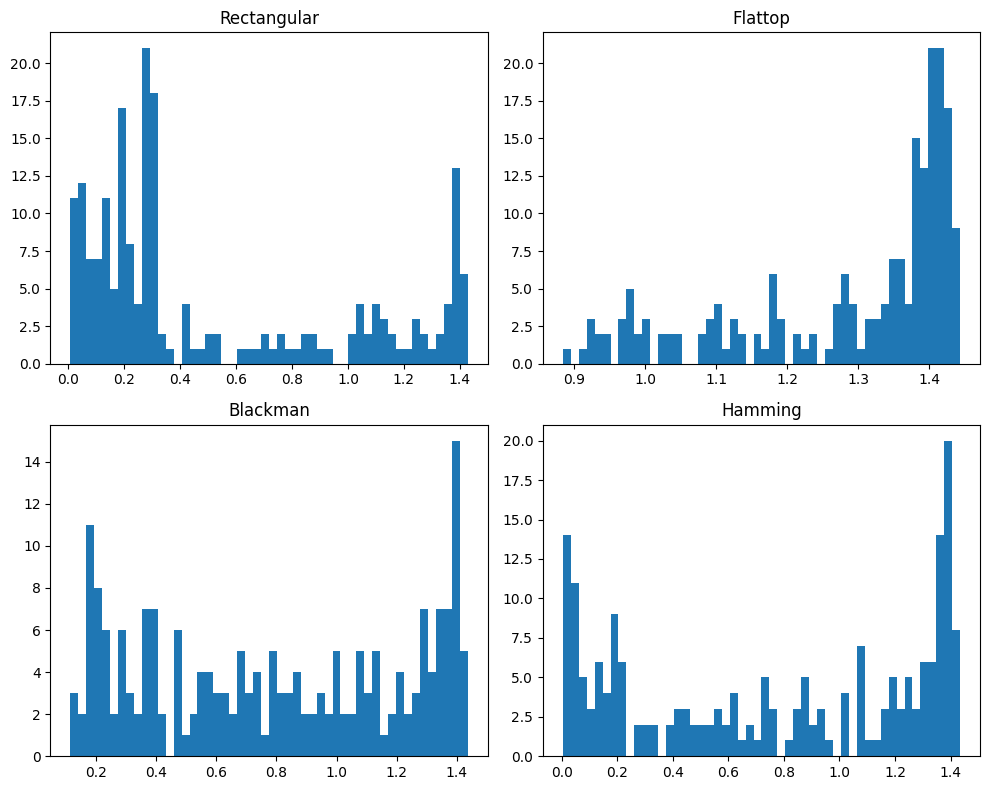

In [131]:
fig, axs = plt.subplots(2, 2, figsize=(10,8))

axs[0,0].hist(a_est["rect"], bins=50)
axs[0,0].set_title("Rectangular")

axs[0,1].hist(a_est["flattop"], bins=50)
axs[0,1].set_title("Flattop")

axs[1,0].hist(a_est["black"], bins=50)
axs[1,0].set_title("Blackman")

axs[1,1].hist(a_est["ham"], bins=50)
axs[1,1].set_title("Hamming")

plt.tight_layout()
plt.show()

In [132]:
win_rect = np.ones(N).reshape(-1,1)
win_flattop = signal.windows.flattop(N).reshape(-1,1)
win_blackman = signal.windows.blackman(N).reshape(-1,1)
win_hamming = signal.windows.hamming(N).reshape(-1,1)

mat_win_rect = np.tile(win_rect, (1, cant_muestras))
mat_win_flattop = np.tile(win_flattop, (1, cant_muestras))
mat_win_blackman = np.tile(win_blackman, (1, cant_muestras))
mat_win_hamming = np.tile(win_hamming, (1, cant_muestras))

mat_win_hamming

array([[0.08      , 0.08      , 0.08      , ..., 0.08      , 0.08      ,
        0.08      ],
       [0.08000227, 0.08000227, 0.08000227, ..., 0.08000227, 0.08000227,
        0.08000227],
       [0.08000909, 0.08000909, 0.08000909, ..., 0.08000909, 0.08000909,
        0.08000909],
       ...,
       [0.08000909, 0.08000909, 0.08000909, ..., 0.08000909, 0.08000909,
        0.08000909],
       [0.08000227, 0.08000227, 0.08000227, ..., 0.08000227, 0.08000227,
        0.08000227],
       [0.08      , 0.08      , 0.08      , ..., 0.08      , 0.08      ,
        0.08      ]], shape=(2000, 200))